# 한국주식 호가 조회와 시세 분석

`Function/KoreanStockQuotes.py`에 만든 한국투자증권 Open API 함수를 실행하고, 현재 호가와 과거 일별 시세를 분석합니다.

In [52]:
import importlib
import os
import sys
from datetime import datetime, timedelta
from pathlib import Path

import FinanceDataReader as fdr
import pandas as pd
import requests

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from Function import KoreanStockQuotes as korean_stock_quotes

korean_stock_quotes = importlib.reload(korean_stock_quotes)
KoreanStockQuoteClient = korean_stock_quotes.KoreanStockQuoteClient
get_domestic_stock_list = korean_stock_quotes.get_domestic_stock_list
analyze_moving_averages = korean_stock_quotes.analyze_moving_averages
analyze_technical_indicators = korean_stock_quotes.analyze_technical_indicators


env_path = project_root / ".env"
if env_path.exists():
    for line in env_path.read_text(encoding="utf-8").splitlines():
        if line.strip() and not line.lstrip().startswith("#") and "=" in line:
            name, value = line.split("=", 1)
            os.environ.setdefault(name.strip(), value.strip())

stock_code = "005930"  # 삼성전자
end_date = datetime.now()
start_date = end_date - timedelta(days=365)
start_date = start_date.strftime("%Y%m%d")
end_date = end_date.strftime("%Y%m%d")

has_kis_credentials = bool(
    os.getenv("KIS_APP_KEY") and os.getenv("KIS_APP_SECRET")
)

print(f"프로젝트 경로: {project_root}")
print(f"종목코드: {stock_code}")
print(f"조회기간: {start_date} ~ {end_date}")
print(f"KIS 인증정보 확인: {'완료' if has_kis_credentials else '없음'}")

프로젝트 경로: c:\Python\3.Equity
종목코드: 005930
조회기간: 20250912 ~ 20260912
KIS 인증정보 확인: 완료


In [40]:
domestic_stock_list = get_domestic_stock_list()
print(f"국내 종목 수: {len(domestic_stock_list):,}개")
display(domestic_stock_list.groupby("시장").size().rename("종목 수").to_frame())
display(domestic_stock_list.head())

국내 종목 수: 2,873개


,종목 수
시장,
KONEX,108
KOSDAQ,1772
KOSDAQ GLOBAL,50
KOSPI,943


,종목코드,종목명,시장
0,000020,동화약품,KOSPI
1,000040,KR모터스,KOSPI
2,000050,경방,KOSPI
3,000070,삼양홀딩스,KOSPI
4,000080,하이트진로,KOSPI


## 인증 설정

다음 두 가지 방법 중 하나로 KIS 인증정보를 준비합니다.

1. `KIS_APP_KEY`, `KIS_APP_SECRET` 환경변수를 설정합니다.
2. 환경변수가 없으면 아래 Python 셀에서 보안 입력창이 표시됩니다.

입력한 키는 노트북 파일에 저장하지 않으며 화면에도 출력하지 않습니다. 과거 시점의 호가창 스냅샷은 표준 API에서 제공되지 않으므로, 과거 데이터는 일별 OHLCV로 조회합니다.

In [46]:
try:
    client = KoreanStockQuoteClient()
    print("KIS 클라이언트가 준비되었습니다.")
except ValueError:
    client = None
    print("KIS 인증정보가 없어 조회를 건너뜁니다.")

KIS 클라이언트가 준비되었습니다.


## 현재 호가

현재 매도·매수 10단 호가와 각 호가의 잔량을 조회합니다. 장중이 아니면 마지막 체결 기준 정보가 반환될 수 있습니다.

In [42]:
if client is not None:
    current_order_book = client.get_current_order_book(stock_code)
    display(current_order_book)
else:
    current_order_book = pd.DataFrame()
    print("인증정보가 없어 현재 호가를 조회하지 않았습니다.")

,호가단계,매도호가,매도잔량,매수호가,매수잔량
0,1,260000,101111,259500,31936
1,2,260500,15092,259000,255896
2,3,261000,42193,258500,297049
3,4,261500,45981,258000,284076
4,5,262000,63051,257500,330917
5,6,262500,34739,257000,400454
6,7,263000,38423,256500,179449
7,8,263500,23117,256000,210709
8,9,264000,32384,255500,158550
9,10,264500,28770,255000,327392


In [43]:
if client is not None:
    realtime_order_books = []
    for realtime_order_book in client.stream_order_book(
        stock_code,
        max_updates=1,
        idle_timeout=5,
    ):
        realtime_order_books.append(realtime_order_book)
        display(realtime_order_book)
    if not realtime_order_books:
        print("5초 동안 새로운 호가가 없어 구독을 종료했습니다.")
else:
    realtime_order_books = []
    print("인증정보가 없어 실시간 호가를 구독하지 않았습니다.")

5초 동안 새로운 호가가 없어 구독을 종료했습니다.


## 과거 일별 시세

지정 기간의 시가·고가·저가·종가·거래량·거래대금을 조회합니다. 긴 기간은 함수가 API 페이지 단위로 자동 수집합니다.

In [48]:
if client is not None:
    try:
        historical_prices = client.get_historical_prices(
            stock_code=stock_code,
            start_date=start_date,
            end_date=end_date,
        )
    except (requests.RequestException, RuntimeError) as error:
        status_code = getattr(getattr(error, "response", None), "status_code", "KIS 오류")
        print(f"KIS 일별 시세 조회 실패({status_code}); 공개 데이터로 전환합니다.")
        fallback_prices = fdr.DataReader(stock_code, start_date, end_date)
        historical_prices = (
            fallback_prices.reset_index()
            .rename(
                columns={
                    "Date": "일자",
                    "Open": "시가",
                    "High": "고가",
                    "Low": "저가",
                    "Close": "종가",
                    "Volume": "거래량",
                }
            )
            .assign(거래대금=pd.NA)
        )
    display(historical_prices.head())
    print(f"조회 건수: {len(historical_prices):,}건")
else:
    historical_prices = pd.DataFrame()
    print("인증정보가 없어 과거 시세를 조회하지 않았습니다.")

KIS 일별 시세 조회 실패(500); 공개 데이터로 전환합니다.


,일자,시가,고가,저가,종가,거래량,Change,거래대금
0,2025-09-12,74600,75600,74200,75400,28219678,0.027248,<NA>
1,2025-09-15,77200,77600,75900,76500,19908805,0.014589,<NA>
2,2025-09-16,76900,79500,76700,79400,28218265,0.037908,<NA>
3,2025-09-17,79100,79100,77100,78200,20856317,-0.015113,<NA>
4,2025-09-18,79100,80500,78600,80500,25619035,0.029412,<NA>


조회 건수: 243건


In [49]:
if not historical_prices.empty:
    moving_average_analysis = analyze_moving_averages(
        historical_prices,
        short_window=20,
        long_window=60,
    )
    display(
        moving_average_analysis[
            ["일자", "종가", "단기이동평균", "장기이동평균", "추세", "신호"]
        ].tail()
    )
    display(moving_average_analysis[moving_average_analysis["신호"] != ""])
else:
    moving_average_analysis = pd.DataFrame()
    print("분석할 과거 시세가 없습니다.")

,일자,종가,단기이동평균,장기이동평균,추세,신호
238,2026-09-07,270000,259075.0,277408.333333,하락,
239,2026-09-08,269500,261050.0,276525.000000,하락,
240,2026-09-09,269500,262550.0,275400.000000,하락,
241,2026-09-10,269000,263225.0,274166.666667,하락,
242,2026-09-11,259500,262800.0,272716.666667,하락,


,일자,시가,고가,저가,종가,거래량,Change,거래대금,단기이동평균,장기이동평균,추세,신호
206,2026-07-22,276000,276000,260000,260500,22292003,0.005792,<NA>,293775.0,294183.333333,하락,데드크로스


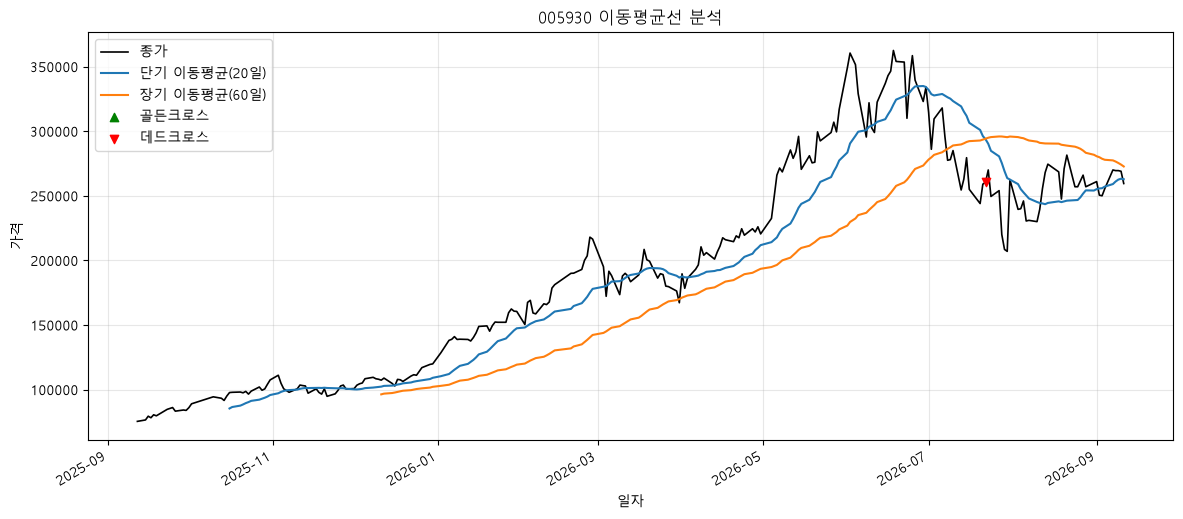

In [50]:
import matplotlib.pyplot as plt
from matplotlib import font_manager

available_fonts = {font.name for font in font_manager.fontManager.ttflist}
korean_font = next(
    (
        font_name
        for font_name in ("Malgun Gothic", "NanumGothic", "AppleGothic")
        if font_name in available_fonts
    ),
    "DejaVu Sans",
)
plt.rcParams["font.family"] = korean_font
plt.rcParams["axes.unicode_minus"] = False

if not moving_average_analysis.empty:
    figure, axis = plt.subplots(figsize=(14, 6))
    axis.plot(
        moving_average_analysis["일자"],
        moving_average_analysis["종가"],
        label="종가",
        color="black",
        linewidth=1.2,
    )
    axis.plot(
        moving_average_analysis["일자"],
        moving_average_analysis["단기이동평균"],
        label="단기 이동평균(20일)",
        color="tab:blue",
    )
    axis.plot(
        moving_average_analysis["일자"],
        moving_average_analysis["장기이동평균"],
        label="장기 이동평균(60일)",
        color="tab:orange",
    )

    golden_crosses = moving_average_analysis[
        moving_average_analysis["신호"] == "골든크로스"
    ]
    dead_crosses = moving_average_analysis[
        moving_average_analysis["신호"] == "데드크로스"
    ]
    axis.scatter(
        golden_crosses["일자"],
        golden_crosses["종가"],
        marker="^",
        color="green",
        label="골든크로스",
        zorder=3,
    )
    axis.scatter(
        dead_crosses["일자"],
        dead_crosses["종가"],
        marker="v",
        color="red",
        label="데드크로스",
        zorder=3,
    )
    axis.set_title(f"{stock_code} 이동평균선 분석")
    axis.set_xlabel("일자")
    axis.set_ylabel("가격")
    axis.grid(True, alpha=0.3)
    axis.legend()
    figure.autofmt_xdate()
    plt.show()

    if moving_average_analysis["장기이동평균"].notna().sum() == 0:
        print("장기 이동평균선은 60일 이상의 시세 데이터가 있어야 표시됩니다.")
else:
    print("분석할 과거 시세가 없습니다.")

## 간단한 분석

조회된 종가로 기간 수익률, 연환산 변동성, 최대 낙폭을 계산합니다.

In [ ]:
if not historical_prices.empty:
    prices = historical_prices.sort_values("일자").copy()
    prices["일별수익률"] = prices["종가"].pct_change()
    prices["누적수익률"] = prices["종가"] / prices["종가"].iloc[0] - 1
    prices["고점"] = prices["종가"].cummax()
    prices["낙폭"] = prices["종가"] / prices["고점"] - 1

    period_return = prices["누적수익률"].iloc[-1]
    annualized_volatility = prices["일별수익률"].std() * (252 ** 0.5)
    maximum_drawdown = prices["낙폭"].min()

    summary = pd.Series(
        {
            "기간 수익률": period_return,
            "연환산 변동성": annualized_volatility,
            "최대 낙폭": maximum_drawdown,
        }
    )
    display(summary.to_frame("값"))
    display(prices[["일자", "종가", "일별수익률", "누적수익률", "낙폭"]].tail())
else:
    print("분석할 과거 시세가 없습니다.")

,값
기간 수익률,-0.011429
연환산 변동성,0.701051
최대 낙폭,-0.123810


,일자,종가,일별수익률,누적수익률,낙폭
25,2026-09-07,270000,0.056751,0.028571,-0.040853
26,2026-09-08,269500,-0.001852,0.026667,-0.042629
27,2026-09-09,269500,0.000000,0.026667,-0.042629
28,2026-09-10,269000,-0.001855,0.024762,-0.044405
29,2026-09-11,259500,-0.035316,-0.011429,-0.078153


## 강한 매수 신호 백테스트

아래 실행 셀의 `BACKTEST_START`부터 `BACKTEST_END`까지 다음 규칙으로 백테스트합니다.

- 현재 공개 종목 목록의 시가총액 상위 `UNIVERSE_SIZE`개를 분석합니다. 과거 상장폐지 종목은 포함되지 않아 생존편향이 있습니다.
- `BACKTEST_SHORT_WINDOW`·`BACKTEST_LONG_WINDOW` 이동평균, RSI, MACD, 볼린저 밴드, 거래량을 사용합니다.
- 매 거래일 매도조건수가 3개 이상인 보유 종목은 해당일 종가로 전량 매도합니다.
- 매도 후 당일 강한 매수 신호 중 종합 점수가 가장 높은 종목 1개를 매수합니다.
- `MAX_INVESTMENT`를 **초기 운용자금**으로 입금합니다. 매수금액은 `UNIT_INVESTMENT`와 현금잔액 중 작은 금액을 한도로 합니다.
- 매수 시 현금을 차감하고 매도 대금을 다시 현금으로 회수합니다. 추가 납입 없이 매도 대금을 재투자합니다.
- **누적 매수금액은 거래 규모를 나타내는 참고값**입니다. 재투자하면 초기 운용자금을 초과할 수 있으며, 매수 중단 조건으로 쓰지 않습니다.
- 수수료, 세금, 슬리피지는 제외하고 종가 체결을 가정합니다.
- 수익률은 `(현금잔액 + 보유주식 평가금액 - 초기 운용자금) / 초기 운용자금`입니다.
- 일별 평가내역의 매수후보수·매수상태·현금잔액으로 미매수 원인을 확인할 수 있습니다. 보유주식 평가금액이 0이어도 매도 대금은 현금으로 남습니다.

## 같은 기간 KOSPI 수익률 비교

백테스트 셀을 실행하면 결과 요약 바로 아래에 비교 표와 수익률 그래프를 표시합니다. `BACKTEST_START`와 `BACKTEST_END`를 그대로 사용하며 실제 비교 시작일과 종료일을 표시합니다.

- **강한 매수 전략**: 현금을 포함한 총자산의 초기 운용자금 대비 수익률입니다.
- **KOSPI 기간 보유**: 같은 초기 운용자금 전액을 기간 내 첫 거래일 종가에 투자하여 마지막 거래일 종가까지 보유한 수익률입니다.
- **전략 초과수익률(%p)**: 전략 수익률에서 KOSPI 수익률을 뺀 값입니다.

KOSPI는 배당을 포함하지 않는 가격지수입니다. 지수는 소수점 단위 매수를 가정하며 양쪽 모두 거래비용을 제외합니다. 지수 조회에 실패하면 안내를 표시하고 나머지 백테스트 결과를 계속 출력합니다.


BACKTEST RUN 2026-09-19T10:18:09 | source 9614800f8c72
BACKTEST SUMMARY


,값
초기 운용자금,1.000000e+09
누적 매수금액(재투자 포함),3.640855e+09
총 매도 실현손익,1.985697e+08
최종 보유종목 평가손익,-3.234664e+07
최종 수익금,1.662231e+08
투자수익률,1.662231e-01
최종 평가금액,1.166223e+09
현금잔액,7.745828e+08
매수 횟수,3.660000e+02
매도 횟수,3.070000e+02


실제 비교 기간: 2025-01-02 ~ 2026-09-11 (거래일 종가 기준)
KOSPI: 2,398.94 → 6,909.91


,초기 운용자금,최종 총자산,수익률(%),전략 초과수익률(%p)
강한 매수 전략,"1,000,000,000.00","1,166,223,102.00",16.62,0.00
KOSPI 기간 보유,"1,000,000,000.00","2,880,401,343.93",188.04,-171.42


전략 수익률은 현금과 보유주식 평가금액을 합한 총자산 기준입니다.
양쪽 모두 동일한 초기 운용자금으로 시작하며 추가 납입은 없습니다.
KOSPI 가격지수 기준이며 배당, 수수료, 세금, 슬리피지는 제외합니다.


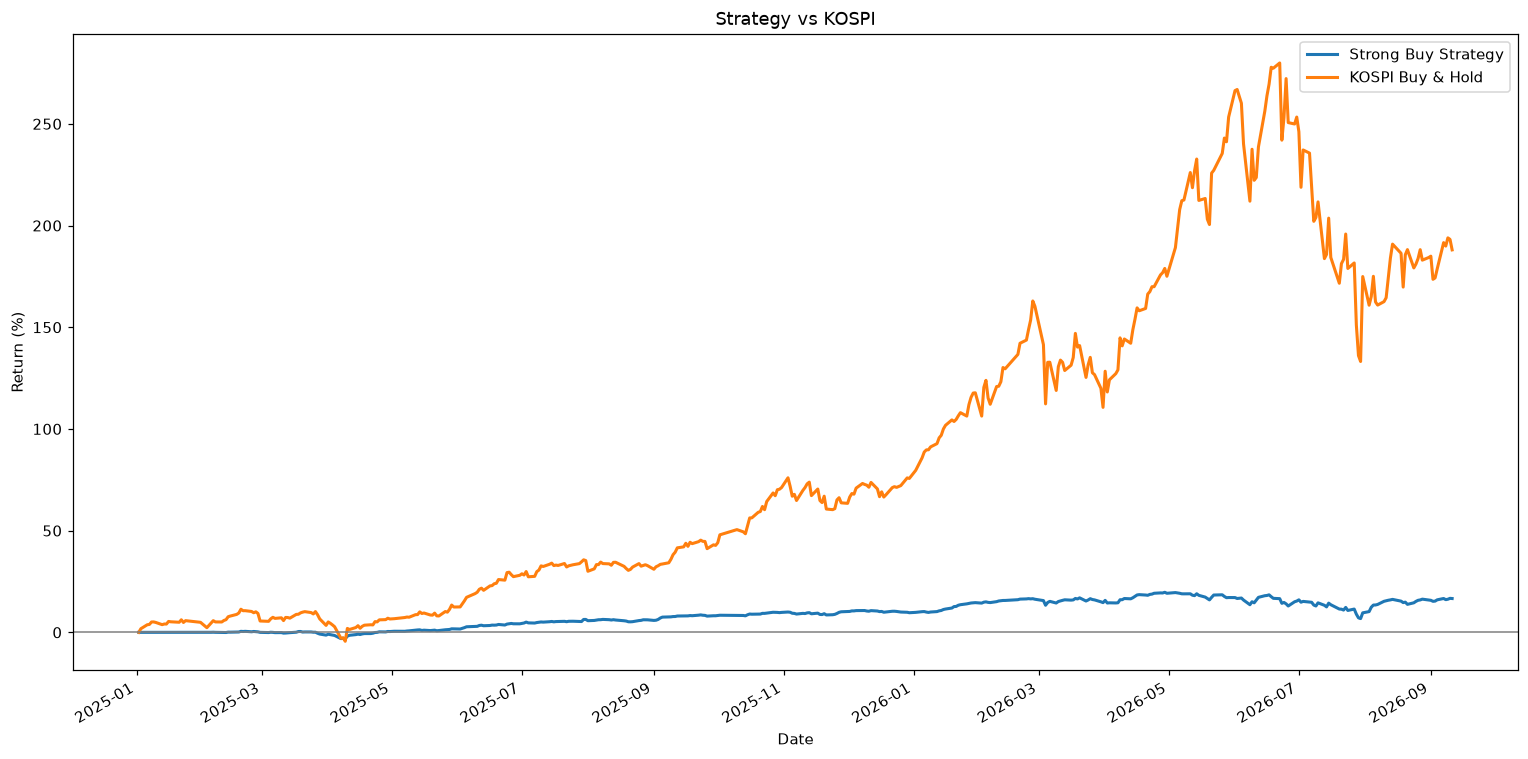


FINAL HOLDINGS


,종목코드,종목명,수량,평균매수가,최종가격,매입원가,평가금액,평가손익,평가수익률
0,036530,SNT홀딩스,173,5.770000e+04,47450.0,9982100.0,8208850.0,-1773250.0,-0.177643
1,000670,영풍,161,6.190000e+04,38450.0,9965900.0,6190450.0,-3775450.0,-0.378837
2,00104K,CJ4우(전환),66,1.499000e+05,126600.0,9893400.0,8355600.0,-1537800.0,-0.155437
3,079550,LIG디펜스앤에어로스페이스,20,9.320000e+05,678000.0,18640000.0,13560000.0,-5080000.0,-0.272532
4,259960,크래프톤,38,2.565000e+05,212500.0,9747000.0,8075000.0,-1672000.0,-0.171540
5,365550,ESR켄달스퀘어리츠,2283,4.380000e+03,3185.0,9999540.0,7271355.0,-2728185.0,-0.272831
6,377300,카카오페이,195,5.110000e+04,46250.0,9964500.0,9018750.0,-945750.0,-0.094912
7,034220,LG디스플레이,1329,1.503391e+04,8900.0,19980060.0,11828100.0,-8151960.0,-0.408005
8,001680,대상,1070,1.867718e+04,18760.0,19984580.0,20073200.0,88620.0,0.004434
9,018880,한온시스템,1893,5.280000e+03,3520.0,9995040.0,6663360.0,-3331680.0,-0.333333



TRADE LOG


,일자,구분,종목코드,종목명,수량,가격,금액,사유,매입원가,실현손익
0,2025-02-04,매수,019210,와이지-원,1893,5280.0,9995040.0,강한 매수 신호 최고점수,NaN,NaN
1,2025-02-05,매수,012630,HDC,782,12780.0,9993960.0,강한 매수 신호 최고점수,NaN,NaN
2,2025-02-06,매수,034220,LG디스플레이,1033,9680.0,9999440.0,강한 매수 신호 최고점수,NaN,NaN
3,2025-02-07,매수,003690,코리안리,1222,8180.0,9995960.0,강한 매수 신호 최고점수,NaN,NaN
4,2025-02-10,매수,005690,파미셀,1031,9690.0,9990390.0,강한 매수 신호 최고점수,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
668,2026-09-10,매도,131290,티에스이,36,306500.0,11034000.0,매도조건수 3개 이상,9972000.0,1062000.0
669,2026-09-10,매도,327260,RF머트리얼즈,236,43400.0,10242400.0,매도조건수 3개 이상,9982800.0,259600.0
670,2026-09-10,매수,000240,한국앤컴퍼니,396,25200.0,9979200.0,강한 매수 신호 최고점수,NaN,NaN
671,2026-09-11,매도,044490,태웅,304,39350.0,11962400.0,매도조건수 3개 이상,9986400.0,1976000.0



DAILY PORTFOLIO VALUATION


,일자,현금잔액,총자산,누적매수금액,매수후보수,매수상태,보유종목수,보유종목매입원가,보유종목평가금액,평가손익,누적실현손익,총손익
0,2025-01-02,1.000000e+09,1.000000e+09,0.000000e+00,0,강한 매수신호 없음,0,0.0,0.0,0.0,0.0,0.0
1,2025-01-03,1.000000e+09,1.000000e+09,0.000000e+00,0,강한 매수신호 없음,0,0.0,0.0,0.0,0.0,0.0
2,2025-01-06,1.000000e+09,1.000000e+09,0.000000e+00,0,강한 매수신호 없음,0,0.0,0.0,0.0,0.0,0.0
3,2025-01-07,1.000000e+09,1.000000e+09,0.000000e+00,0,강한 매수신호 없음,0,0.0,0.0,0.0,0.0,0.0
4,2025-01-08,1.000000e+09,1.000000e+09,0.000000e+00,0,강한 매수신호 없음,0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
437,2026-09-07,7.527215e+08,1.166423e+09,3.600908e+09,5,매수 체결,40,443375550.0,413701275.0,-29674275.0,196097017.0,166422742.0
438,2026-09-08,7.531787e+08,1.160723e+09,3.610904e+09,2,매수 체결,40,443381390.0,407544500.0,-35836890.0,196560137.0,160723247.0
439,2026-09-09,7.431959e+08,1.162802e+09,3.620887e+09,5,매수 체결,41,453364190.0,419606510.0,-33757680.0,196560137.0,162802457.0
440,2026-09-10,7.726091e+08,1.167218e+09,3.630866e+09,3,매수 체결,39,423984590.0,394608935.0,-29375655.0,196593737.0,167218082.0


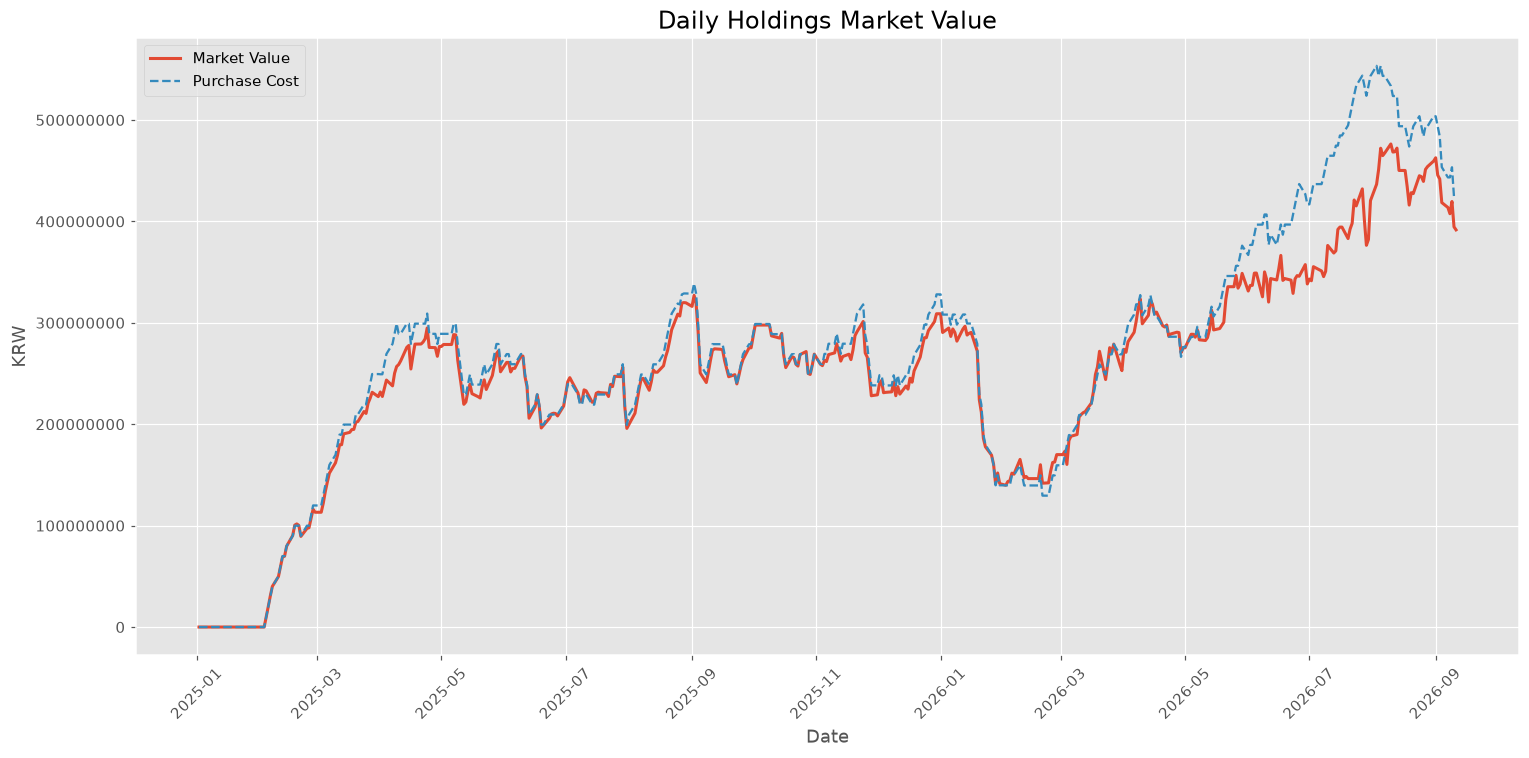

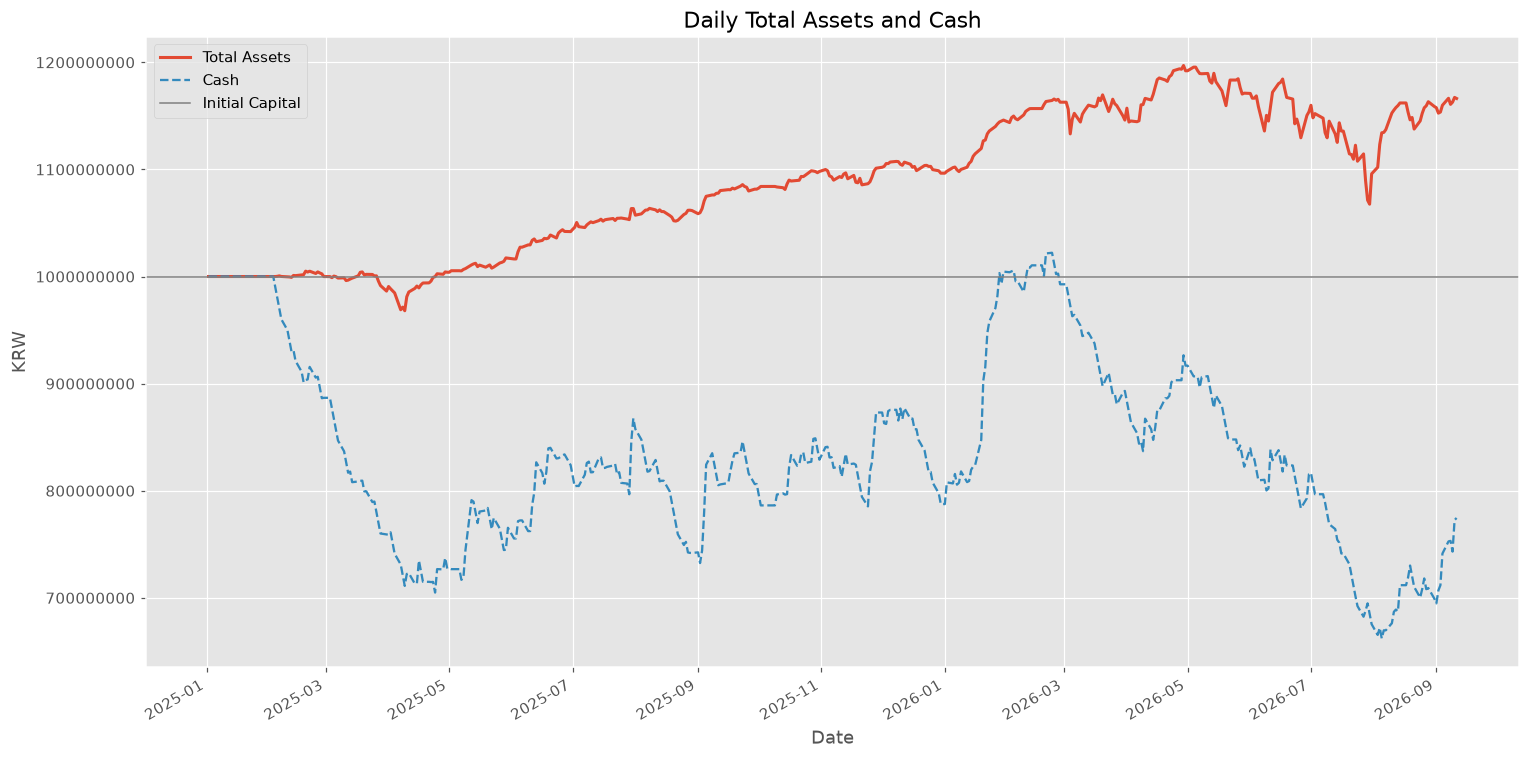

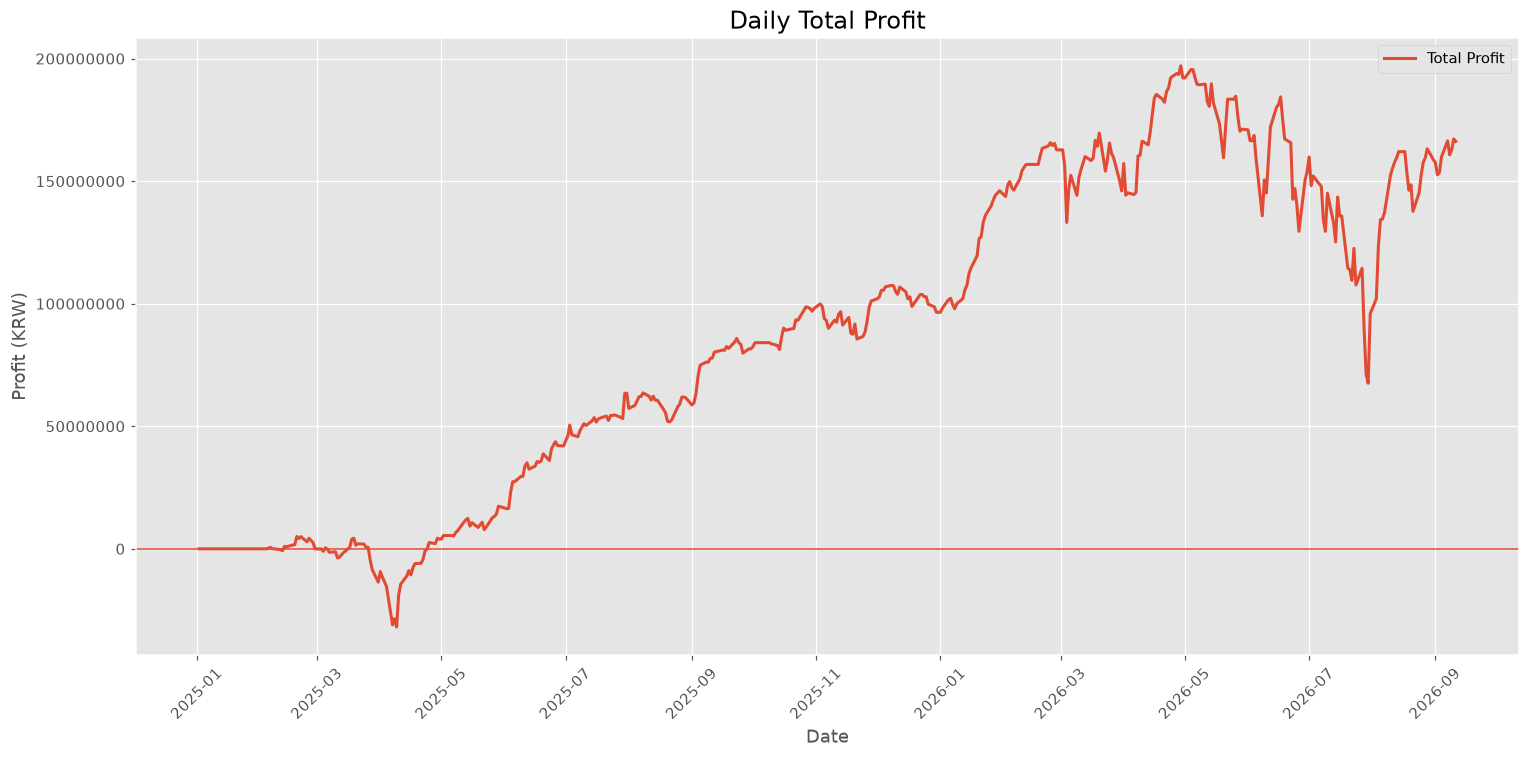

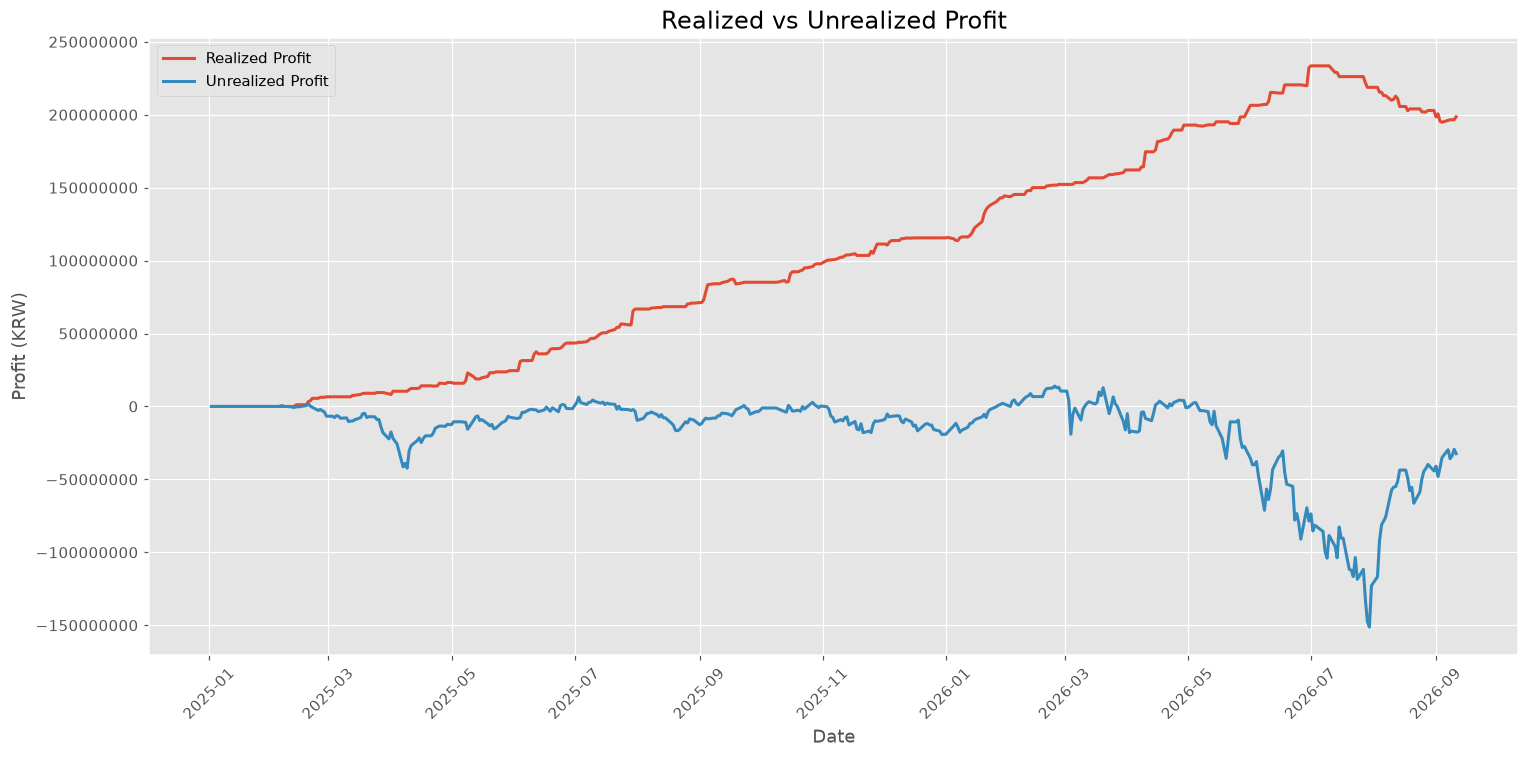


ACTUAL RUN DIAGNOSTICS
Loaded stocks: 498
Initial capital: 1,000,000,000
Buy count: 366
Last buy: 2026-09-11
일자
2025-02    19
2025-03    20
2025-04    18
2025-05    19
2025-06    19
2025-07    21
2025-08    20
2025-09    21
2025-10    17
2025-11    19
2025-12    19
2026-01    21
2026-02    16
2026-03    20
2026-04    17
2026-05    18
2026-06    17
2026-07    20
2026-08    16
2026-09     9
Freq: M
                  초기 운용자금        최종 총자산      수익률(%)  전략 초과수익률(%p)
강한 매수 전략     1.000000e+09  1.166223e+09   16.622310      0.000000
KOSPI 기간 보유  1.000000e+09  2.880401e+09  188.040134   -171.417824


In [1]:
from concurrent.futures import ThreadPoolExecutor, as_completed

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. Backtest Parameters
# ============================================================

BACKTEST_START = pd.Timestamp("2025-01-02")
BACKTEST_END = pd.Timestamp("2026-09-12")

UNIT_INVESTMENT = 10_000_000
MAX_INVESTMENT = 1_000_000_000

BACKTEST_SHORT_WINDOW = 5
BACKTEST_LONG_WINDOW = 20

UNIVERSE_SIZE = 500


# ============================================================
# 2. Universe
# ============================================================

universe = (
    fdr.StockListing("KRX")[["Code", "Name", "Market", "Marcap"]]
    .dropna()
)

universe = (
    universe
    .sort_values("Marcap", ascending=False)
    .head(UNIVERSE_SIZE)
    .reset_index(drop=True)
)


# ============================================================
# 3. Historical Price
# ============================================================

def load_backtest_history(stock_code):

    history = fdr.DataReader(
        stock_code,
        "20250101",
        BACKTEST_END.strftime("%Y%m%d")
    ).reset_index()

    return history.rename(
        columns={
            "Date": "일자",
            "Open": "시가",
            "High": "고가",
            "Low": "저가",
            "Close": "종가",
            "Volume": "거래량",
        }
    )


# ============================================================
# 4. Technical Indicators
# ============================================================

def prepare_history(stock_code):

    try:

        history = load_backtest_history(stock_code)

        if len(history) < BACKTEST_LONG_WINDOW:
            return stock_code, None

        analysis = analyze_technical_indicators(
            history,
            BACKTEST_SHORT_WINDOW,
            BACKTEST_LONG_WINDOW
        )

        analysis["단기선기울기"] = (
            analysis["단기이동평균"].pct_change(5)
        )

        return stock_code, analysis

    except Exception:

        return stock_code, None


# ============================================================
# 5. Parallel Loading
# ============================================================

indicator_histories = {}

with ThreadPoolExecutor(max_workers=8) as executor:

    futures = [
        executor.submit(
            prepare_history,
            code
        )
        for code in universe["Code"]
    ]

    for future in as_completed(futures):

        code, analysis = future.result()

        if analysis is not None:
            indicator_histories[code] = analysis


# ============================================================
# 6. Signal Score
# ============================================================

def calculate_signal_score(row):

    if (
        pd.isna(row["단기이동평균"])
        or pd.isna(row["장기이동평균"])
    ):
        return float("-inf")

    gap = (
        row["단기이동평균"]
        - row["장기이동평균"]
    ) / row["장기이동평균"]

    slope = (
        row["단기선기울기"]
        if pd.notna(row["단기선기울기"])
        else 0
    )

    score = (
        max(
            0,
            100 - abs(gap) * 1400
        )
        +
        max(
            0,
            min(
                30,
                slope * 1500
            )
        )
    )

    if row["강한신호"] == "강한 매수":
        score += 25

    return score


# ============================================================
# 7. Portfolio Variables
# ============================================================

holdings = {}

trade_log = []

# 초기자금은 한 번만 입금하고 매도 대금은 재투자합니다.
initial_capital = float(MAX_INVESTMENT)
if initial_capital <= 0 or UNIT_INVESTMENT <= 0:
    raise ValueError("초기 운용자금과 회당 매수한도는 0보다 커야 합니다.")
cash = initial_capital

# 누적 거래금액이며 매수 한도로 사용하지 않습니다.
total_purchased = 0.0


# ============================================================
# 매도로 인한 누적 실현손익
# ============================================================

total_realized_profit = 0.0


# ============================================================
# 추가
# 일별 포트폴리오 평가내역
# ============================================================

daily_portfolio_log = []


# ============================================================
# 8. Trading Dates
# ============================================================

trading_dates = pd.date_range(
    BACKTEST_START,
    BACKTEST_END,
    freq="B"
)


# ============================================================
# 9. Backtest
# ============================================================

for trading_date in trading_dates:

    buy_candidates = []
    available_price_count = 0


    # ========================================================
    # A. 종목별 매수/매도 판단
    # ========================================================

    for code, analysis in indicator_histories.items():

        rows = analysis[
            analysis["일자"] == trading_date
        ]

        if rows.empty:
            continue

        row = rows.iloc[-1]
        available_price_count += 1


        # ====================================================
        # A-1. 매도
        # 기존 조건 그대로
        # ====================================================

        if (
            code in holdings
            and row["매도신호수"] >= 3
        ):

            holding = holdings.pop(code)


            sale_amount = (
                holding["quantity"]
                * float(row["종가"])
            )


            # ------------------------------------------------
            # 매입원가
            # ------------------------------------------------

            purchase_cost = (
                holding["cost"]
            )


            # ------------------------------------------------
            # 실현손익
            # ------------------------------------------------

            realized_profit = (
                sale_amount
                - purchase_cost
            )


            # ------------------------------------------------
            # 누적 실현손익
            # ------------------------------------------------

            total_realized_profit += (
                realized_profit
            )


            cash += sale_amount


            trade_log.append(
                {
                    "일자": trading_date,

                    "구분": "매도",

                    "종목코드": code,

                    "종목명": holding[
                        "name"
                    ],

                    "수량": holding[
                        "quantity"
                    ],

                    "가격": float(
                        row["종가"]
                    ),

                    "금액": sale_amount,

                    "매입원가": (
                        purchase_cost
                    ),

                    "실현손익": (
                        realized_profit
                    ),

                    "사유": (
                        "매도조건수 3개 이상"
                    ),
                }
            )


        # ====================================================
        # A-2. 매수 후보
        # 기존 조건 그대로
        # ====================================================

        if (
            row["강한신호"]
            == "강한 매수"
        ):

            buy_candidates.append(
                (
                    calculate_signal_score(
                        row
                    ),
                    code,
                    row
                )
            )


    # ========================================================
    # B. 매수
    # 기존 조건 그대로
    # ========================================================

    if not available_price_count:
        buy_status = "시세 없음(휴장/데이터 누락)"
    elif not buy_candidates:
        buy_status = "강한 매수신호 없음"
    else:
        buy_status = "매수가능 현금 부족"

    if (
        cash > 0
        and buy_candidates
    ):

        score, code, row = max(
            buy_candidates,
            key=lambda item: item[0]
        )


        buy_budget = min(
            UNIT_INVESTMENT,
            cash
        )


        close_price = float(
            row["종가"]
        )


        quantity = int(
            buy_budget
            // close_price
        )


        if quantity <= 0:
            buy_status = "최고점수 종목 1주 가격이 매수예산 초과"

        if quantity > 0:

            purchase_amount = (
                quantity
                * close_price
            )


            name = universe.loc[
                universe["Code"]
                == code,
                "Name"
            ].iloc[0]


            holding = (
                holdings.setdefault(
                    code,
                    {
                        "name": name,
                        "quantity": 0,
                        "cost": 0.0
                    }
                )
            )


            holding["quantity"] += (
                quantity
            )


            holding["cost"] += (
                purchase_amount
            )


            cash -= purchase_amount
            total_purchased += purchase_amount
            buy_status = "매수 체결"


            trade_log.append(
                {
                    "일자": trading_date,

                    "구분": "매수",

                    "종목코드": code,

                    "종목명": name,

                    "수량": quantity,

                    "가격": close_price,

                    "금액": purchase_amount,

                    "사유": (
                        "강한 매수 신호 최고점수"
                    ),
                }
            )


    # ========================================================
    # C. 추가
    # 당일 보유 종목 평가
    # ========================================================

    daily_holdings_value = 0.0
    daily_holdings_cost = 0.0

    valid_price_count = 0


    for holding_code, holding in holdings.items():

        holding_analysis = (
            indicator_histories[
                holding_code
            ]
        )


        # ----------------------------------------------------
        # 당일까지 존재하는 가장 최근 종가
        # ----------------------------------------------------

        holding_rows = holding_analysis[
            holding_analysis["일자"]
            <= trading_date
        ]


        if holding_rows.empty:
            continue


        latest_row = (
            holding_rows.iloc[-1]
        )


        latest_price = float(
            latest_row["종가"]
        )


        # ----------------------------------------------------
        # 해당 종목 평가금액
        # ----------------------------------------------------

        stock_market_value = (
            holding["quantity"]
            * latest_price
        )


        daily_holdings_value += (
            stock_market_value
        )


        daily_holdings_cost += (
            holding["cost"]
        )


        valid_price_count += 1


    # ========================================================
    # 보유종목 평가손익
    # ========================================================

    daily_unrealized_profit = (
        daily_holdings_value
        - daily_holdings_cost
    )


    # ========================================================
    # 실현손익 + 평가손익
    # ========================================================

    daily_total_profit = (
        total_realized_profit
        + daily_unrealized_profit
    )


    # ========================================================
    # 일별 결과 저장
    # ========================================================

    daily_portfolio_log.append(
        {
            "일자": trading_date,

            "현금잔액": cash,
            "총자산": cash + daily_holdings_value,
            "누적매수금액": total_purchased,
            "매수후보수": len(buy_candidates),
            "매수상태": buy_status,

            "보유종목수": len(
                holdings
            ),

            "보유종목매입원가": (
                daily_holdings_cost
            ),

            "보유종목평가금액": (
                daily_holdings_value
            ),

            "평가손익": (
                daily_unrealized_profit
            ),

            "누적실현손익": (
                total_realized_profit
            ),

            "총손익": (
                daily_total_profit
            ),
        }
    )


# ============================================================
# 10. Final Holdings
# ============================================================

final_holdings = []

final_value = cash


# ============================================================
# 최종 보유종목 평가손익
# ============================================================

total_unrealized_profit = 0.0


for code, holding in holdings.items():

    analysis = indicator_histories[
        code
    ]


    rows = analysis[
        analysis["일자"]
        <= BACKTEST_END
    ]


    final_price = float(
        rows.iloc[-1]["종가"]
    )


    market_value = (
        holding["quantity"]
        * final_price
    )


    final_value += (
        market_value
    )


    # ========================================================
    # 평가손익
    # ========================================================

    unrealized_profit = (
        market_value
        - holding["cost"]
    )


    total_unrealized_profit += (
        unrealized_profit
    )


    final_holdings.append(
        {
            "종목코드": code,

            "종목명": holding[
                "name"
            ],

            "수량": holding[
                "quantity"
            ],

            "평균매수가": (
                holding["cost"]
                / holding["quantity"]
            ),

            "최종가격": (
                final_price
            ),

            "매입원가": (
                holding["cost"]
            ),

            "평가금액": (
                market_value
            ),

            "평가손익": (
                unrealized_profit
            ),

            "평가수익률": (
                unrealized_profit
                / holding["cost"]
                if holding["cost"] > 0
                else 0
            ),
        }
    )


# ============================================================
# 11. DataFrame Conversion
# ============================================================

trade_log = pd.DataFrame(
    trade_log
)

final_holdings = pd.DataFrame(
    final_holdings
)

daily_portfolio = pd.DataFrame(
    daily_portfolio_log
)


# ============================================================
# 12. Final Profit
# ============================================================

final_profit = (
    total_realized_profit
    + total_unrealized_profit
)


return_rate = (
    final_profit
    / initial_capital
)


# ============================================================
# 13. Backtest Summary
# ============================================================

backtest_summary = pd.Series(
    {
        "초기 운용자금": initial_capital,

        "누적 매수금액(재투자 포함)": (
            total_purchased
        ),

        "총 매도 실현손익": (
            total_realized_profit
        ),

        "최종 보유종목 평가손익": (
            total_unrealized_profit
        ),

        "최종 수익금": (
            final_profit
        ),

        "투자수익률": (
            return_rate
        ),

        "최종 평가금액": (
            final_value
        ),

        "현금잔액": (
            cash
        ),

        "매수 횟수": (
            int(
                (
                    trade_log["구분"]
                    == "매수"
                ).sum()
            )
            if not trade_log.empty
            else 0
        ),

        "매도 횟수": (
            int(
                (
                    trade_log["구분"]
                    == "매도"
                ).sum()
            )
            if not trade_log.empty
            else 0
        ),
    }
)


# ============================================================
# 14. Result
# ============================================================

print("=" * 90)
print("BACKTEST SUMMARY")
print("=" * 90)

display(
    backtest_summary.to_frame(
        "값"
    )
)


# ============================================================
# KOSPI Benchmark Comparison
# ============================================================

# 같은 초기자금·기간 기준 KOSPI 수익률 비교
import FinanceDataReader as fdr


def build_kospi_comparison(daily_portfolio, kospi_history, initial_capital):
    if initial_capital <= 0:
        raise ValueError("초기 운용자금은 0보다 커야 합니다.")
    portfolio = daily_portfolio.set_index("일자").sort_index().copy()
    portfolio.index = pd.to_datetime(portfolio.index).normalize()
    if portfolio.empty:
        raise ValueError("백테스트의 일별 평가내역이 없습니다.")
    if kospi_history.empty or "Close" not in kospi_history.columns:
        raise ValueError("KOSPI 데이터를 조회하지 못했습니다.")

    close = pd.to_numeric(kospi_history["Close"], errors="coerce").dropna()
    close.index = pd.to_datetime(close.index).tz_localize(None).normalize()
    close = close.sort_index()
    close = close[~close.index.duplicated(keep="last")]
    close = close.loc[portfolio.index.min():portfolio.index.max()]
    if close.empty or (close <= 0).any():
        raise ValueError("해당 기간의 유효한 KOSPI 종가가 없습니다.")
    if not close.index.isin(portfolio.index).all():
        raise ValueError("KOSPI 거래일에 대응하는 백테스트 평가내역이 없습니다.")

    comparison = portfolio.loc[close.index, ["현금잔액", "총자산", "총손익"]].copy()
    comparison.index.name = "일자"
    comparison["전략 수익률(%)"] = (comparison["총자산"] / initial_capital - 1) * 100
    comparison["KOSPI 종가"] = close
    comparison["KOSPI 기간 수익률(%)"] = (close / close.iloc[0] - 1) * 100
    comparison["KOSPI 평가금액"] = initial_capital * close / close.iloc[0]
    return comparison


kospi_comparison = None
kospi_comparison_summary = None

try:
    kospi_history = fdr.DataReader(
        "KS11",
        BACKTEST_START.strftime("%Y-%m-%d"),
        BACKTEST_END.strftime("%Y-%m-%d"),
    )
    kospi_comparison = build_kospi_comparison(
        daily_portfolio, kospi_history, initial_capital
    )
except Exception as exc:
    print(f"KOSPI 비교 불가: {exc}\n네트워크 상태와 조회 기간을 확인한 뒤 다시 실행하세요.")
else:
    first = kospi_comparison.iloc[0]
    last = kospi_comparison.iloc[-1]
    print(
        f"실제 비교 기간: {kospi_comparison.index[0]:%Y-%m-%d}"
        f" ~ {kospi_comparison.index[-1]:%Y-%m-%d} (거래일 종가 기준)"
    )
    print(f"KOSPI: {first['KOSPI 종가']:,.2f} → {last['KOSPI 종가']:,.2f}")
    kospi_comparison_summary = pd.DataFrame(
        {
            "초기 운용자금": [initial_capital, initial_capital],
            "최종 총자산": [last["총자산"], last["KOSPI 평가금액"]],
            "수익률(%)": [last["전략 수익률(%)"], last["KOSPI 기간 수익률(%)"]],
        },
        index=["강한 매수 전략", "KOSPI 기간 보유"],
    )
    kospi_comparison_summary["전략 초과수익률(%p)"] = (
        last["전략 수익률(%)"] - kospi_comparison_summary["수익률(%)"]
    )
    # DataFrame.style은 jinja2가 필요하므로 일반 표로 출력합니다.
    display(kospi_comparison_summary.apply(
        lambda column: column.map(
            lambda value: f"{value:,.2f}" if pd.notna(value) else "해당 없음"
        )
    ))
    print("전략 수익률은 현금과 보유주식 평가금액을 합한 총자산 기준입니다.")
    print("양쪽 모두 동일한 초기 운용자금으로 시작하며 추가 납입은 없습니다.")
    print("KOSPI 가격지수 기준이며 배당, 수수료, 세금, 슬리피지는 제외합니다.")

    fig, ax = plt.subplots(figsize=(14, 7))
    for column, label in [
        ("전략 수익률(%)", "Strong Buy Strategy"),
        ("KOSPI 기간 수익률(%)", "KOSPI Buy & Hold"),
    ]:
        ax.plot(kospi_comparison.index, kospi_comparison[column],
                linewidth=2, label=label)
    ax.axhline(0, color="gray", linewidth=1)
    ax.set(title="Strategy vs KOSPI", xlabel="Date", ylabel="Return (%)")
    ax.legend()
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()


print()
print("=" * 90)
print("FINAL HOLDINGS")
print("=" * 90)

display(
    final_holdings
)


print()
print("=" * 90)
print("TRADE LOG")
print("=" * 90)

display(
    trade_log
)


print()
print("=" * 90)
print("DAILY PORTFOLIO VALUATION")
print("=" * 90)

display(
    daily_portfolio
)


# ============================================================
# 15. Plot
# ggplot2 Style
# ============================================================

plt.style.use("ggplot")


# ============================================================
# Graph 1
# 일별 보유종목 평가금액
# ============================================================

fig, ax = plt.subplots(
    figsize=(14, 7)
)


ax.plot(
    daily_portfolio["일자"],
    daily_portfolio["보유종목평가금액"],
    linewidth=2,
    label="Market Value"
)


ax.plot(
    daily_portfolio["일자"],
    daily_portfolio["보유종목매입원가"],
    linewidth=1.5,
    linestyle="--",
    label="Purchase Cost"
)


ax.set_title(
    "Daily Holdings Market Value",
    fontsize=16
)

ax.set_xlabel(
    "Date"
)

ax.set_ylabel(
    "KRW"
)


ax.legend()


ax.ticklabel_format(
    style="plain",
    axis="y"
)


plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()


# ============================================================
# 현금을 포함한 전체 운용자산
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(daily_portfolio["일자"], daily_portfolio["총자산"], label="Total Assets", linewidth=2)
ax.plot(daily_portfolio["일자"], daily_portfolio["현금잔액"], label="Cash", linestyle="--")
ax.axhline(initial_capital, color="gray", linewidth=1, label="Initial Capital")
ax.set(title="Daily Total Assets and Cash", xlabel="Date", ylabel="KRW")
ax.ticklabel_format(style="plain", axis="y")
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


# ============================================================
# Graph 2
# 일별 총손익
# ============================================================

fig, ax = plt.subplots(
    figsize=(14, 7)
)


ax.plot(
    daily_portfolio["일자"],
    daily_portfolio["총손익"],
    linewidth=2,
    label="Total Profit"
)


ax.axhline(
    y=0,
    linewidth=1
)


ax.set_title(
    "Daily Total Profit",
    fontsize=16
)


ax.set_xlabel(
    "Date"
)

ax.set_ylabel(
    "Profit (KRW)"
)


ax.legend()


ax.ticklabel_format(
    style="plain",
    axis="y"
)


plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()


# ============================================================
# Graph 3
# 실현손익 vs 평가손익
# ============================================================

fig, ax = plt.subplots(
    figsize=(14, 7)
)


ax.plot(
    daily_portfolio["일자"],
    daily_portfolio["누적실현손익"],
    linewidth=2,
    label="Realized Profit"
)


ax.plot(
    daily_portfolio["일자"],
    daily_portfolio["평가손익"],
    linewidth=2,
    label="Unrealized Profit"
)


ax.set_title(
    "Realized vs Unrealized Profit",
    fontsize=16
)


ax.set_xlabel(
    "Date"
)

ax.set_ylabel(
    "Profit (KRW)"
)


ax.legend()


ax.ticklabel_format(
    style="plain",
    axis="y"
)


plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()